In [13]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
fdtdApi = lumapi.FDTD(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


GEOMETRIA DO DISPOSITIVO

In [14]:
# Variáveis auxiliares

microns = 1e-6

largura_guia = 0.45 *microns
altura_guia = 0.22 *microns

largura_taper = 1.5*microns
comprimento_taper = 15 *microns

Wm = 7 *microns
We = 7.156 *microns
L = 176 *microns

comprimento_porta = 4 *microns

In [ ]:
def geometriaMMI():
    # Caixa central

    fdtdApi.addrect()
    fdtdApi.set("name", "Caixa central")
    fdtdApi.set("x span", L)
    fdtdApi.set("y span", Wm)
    fdtdApi.set("z span", altura_guia)
    fdtdApi.set("x", 0)
    fdtdApi.set("y", 0)
    fdtdApi.set("z", 0)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    # Tapers

    fdtdApi.addobject("linear_taper")
    fdtdApi.set("name", "taper1")
    fdtdApi.set("thickness", altura_guia)
    fdtdApi.set("width_l", largura_guia)
    fdtdApi.set("width_r", largura_taper)
    fdtdApi.set("len", comprimento_taper)
    fdtdApi.set("x", -(L/2 + comprimento_taper/2))
    fdtdApi.set("y", We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("angle_side", 90)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addobject("linear_taper")
    fdtdApi.set("name", "taper2")
    fdtdApi.set("thickness", altura_guia)
    fdtdApi.set("width_l", largura_guia)
    fdtdApi.set("width_r", largura_taper)
    fdtdApi.set("len", comprimento_taper)
    fdtdApi.set("x", -(L/2 + comprimento_taper/2))
    fdtdApi.set("y", -We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("angle_side", 90)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addobject("linear_taper")
    fdtdApi.set("name", "taper3")
    fdtdApi.set("thickness", altura_guia)
    fdtdApi.set("width_l", largura_taper)
    fdtdApi.set("width_r", largura_guia)
    fdtdApi.set("len", comprimento_taper)
    fdtdApi.set("x", L/2 + comprimento_taper/2)
    fdtdApi.set("y", We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("angle_side", 90)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addobject("linear_taper")
    fdtdApi.set("name", "taper4")
    fdtdApi.set("thickness", altura_guia)
    fdtdApi.set("width_l", largura_taper)
    fdtdApi.set("width_r", largura_guia)
    fdtdApi.set("len", comprimento_taper)
    fdtdApi.set("x", L/2 + comprimento_taper/2)
    fdtdApi.set("y", -We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("angle_side", 90)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    # Guias Retos

    fdtdApi.addrect()
    fdtdApi.set("name", "porta1")
    fdtdApi.set("x span", comprimento_porta)
    fdtdApi.set("y span", largura_guia)
    fdtdApi.set("z span", altura_guia)
    fdtdApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    fdtdApi.set("y", We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addrect()
    fdtdApi.set("name", "porta2")
    fdtdApi.set("x span", comprimento_porta)
    fdtdApi.set("y span", largura_guia)
    fdtdApi.set("z span", altura_guia)
    fdtdApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    fdtdApi.set("y", -We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addrect()
    fdtdApi.set("name", "porta3")
    fdtdApi.set("x span", comprimento_porta)
    fdtdApi.set("y span", largura_guia)
    fdtdApi.set("z span", altura_guia)
    fdtdApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    fdtdApi.set("y", We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("material", "Si (Silicon) - Palik")

    fdtdApi.addrect()
    fdtdApi.set("name", "porta4")
    fdtdApi.set("x span", comprimento_porta)
    fdtdApi.set("y span", largura_guia)
    fdtdApi.set("z span", altura_guia)
    fdtdApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    fdtdApi.set("y", -We/6)
    fdtdApi.set("z", 0)
    fdtdApi.set("material", "Si (Silicon) - Palik")

REGIÃO DE SIMULAÇÃO

In [16]:
# Margem na região de simulação
x_offset = 0.5 *microns
y_offset = 2 *microns
z_offset = 0.5 *microns

In [ ]:
def regiaosimulacao(m):
    # Adicionando solver

    fdtdApi.addfdtd()
    fdtdApi.set("background material", "SiO2 (Glass) - Palik")

    fdtdApi.set("x", 0) # X = Xspan do dispositivo /2
    fdtdApi.set("y", 0) # O centro é em y = radius
    fdtdApi.set("z", 0)
    fdtdApi.set("x span", L + 2*comprimento_taper + comprimento_porta)
    fdtdApi.set("y span", Wm + 2*y_offset)

    fdtdApi.set('global source wavelength start', 1.5 *microns)
    fdtdApi.set('global source wavelength stop', 1.6 *microns)
    fdtdApi.set('global monitor frequency points', 21)
    fdtdApi.set('Mesh accuracy', 5)
    fdtdApi.set('simulation time', 3.5*(10**(-12)))
    if (m==1):
        fdtdApi.set('z min bc', 'Symmetric')
    else:
        fdtdApi.set('z min bc', 'Anti-Symmetric')

    ## add ports 

    fdtdApi.addport()
    fdtdApi.set('name', 'porta1')
    fdtdApi.set('injection axis', 'x-axis')
    fdtdApi.set('direction', 'Forward')
    fdtdApi.set('x', -(L/2 + comprimento_taper + comprimento_porta/4))
    fdtdApi.set('y', We/6)
    fdtdApi.set('z', 0)
    fdtdApi.set('y span', 2*microns)
    fdtdApi.set('z span', 2*microns)

    fdtdApi.addport()
    fdtdApi.set('name', 'porta2')
    fdtdApi.set('injection axis', 'x-axis')
    fdtdApi.set('direction', 'Forward')
    fdtdApi.set('x', -(L/2 + comprimento_taper + comprimento_porta/4) + 0.1 *microns)
    fdtdApi.set('y', -We/6)
    fdtdApi.set('z', 0)
    fdtdApi.set('y span', 2*microns)
    fdtdApi.set('z span', 2*microns)

    fdtdApi.addport()
    fdtdApi.set('name', 'porta3')
    fdtdApi.set('injection axis', 'x-axis')
    fdtdApi.set('direction', 'Backward')
    fdtdApi.set('x', L/2 + comprimento_taper + comprimento_porta/4)
    fdtdApi.set('y', We/6)
    fdtdApi.set('z', 0)
    fdtdApi.set('y span', 2*microns)
    fdtdApi.set('z span', 2*microns)

    fdtdApi.addport()
    fdtdApi.set('name', 'porta4')
    fdtdApi.set('injection axis', 'x-axis')
    fdtdApi.set('direction', 'Backward')
    fdtdApi.set('x', L/2 + comprimento_taper + comprimento_porta/4)
    fdtdApi.set('y', -We/6)
    fdtdApi.set('z', 0)
    fdtdApi.set('y span', 2*microns)
    fdtdApi.set('z span', 2*microns)

    ## add monitors

    fdtdApi.addprofile()
    fdtdApi.set('name', 'profile')
    fdtdApi.set('override global monitor settings', True)
    fdtdApi.set('frequency points', 21)
    fdtdApi.set('x', 0)
    fdtdApi.set('x span', L + 2*comprimento_taper + comprimento_porta)
    fdtdApi.set('y', 0)
    fdtdApi.set('y span',  Wm + 2*y_offset)
    fdtdApi.set('z', 0)

    fdtdApi.addmovie()
    fdtdApi.set('name', 'movie')
    fdtdApi.set('x', 0)
    fdtdApi.set('x span', L + 2*comprimento_taper + comprimento_porta)
    fdtdApi.set('y', 0)
    fdtdApi.set('y span', Wm + 2*y_offset)
    fdtdApi.set('z', 0)

    ## Salva o arquivo
    fdtdApi.save('MMI_FDTD')

In [ ]:
geometriaMMI()
regiaosimulacao(0)
fdtdApi.run()

Perfil de campo

In [20]:
# importa o campo elétrico - abs
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile')))

indxLambda = np.argmin(np.abs(nu2lambda(fdtdApi.getdata('profile', 'f')) - 1.55 *microns))
x_efield = fdtdApi.getdata('profile', 'x')
y_efield = fdtdApi.getdata('profile', 'y')
wavelength_array = nu2lambda(fdtdApi.getdata('profile', 'f'))[:,0]
xmin = np.min(x_efield) / microns
xmax = np.max(x_efield) / microns
ymin = np.min(y_efield) / microns
ymax = np.max(y_efield) / microns

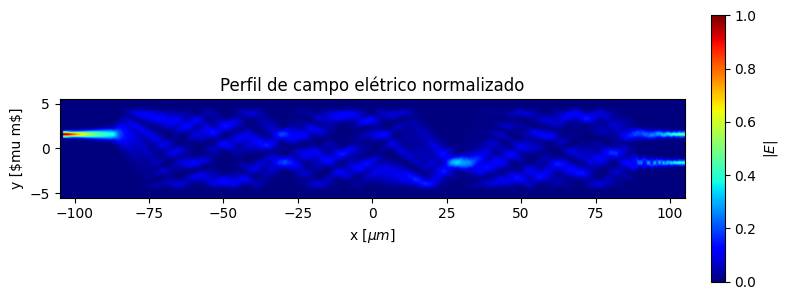

In [27]:
# Escala linear
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)

im = ax.imshow(np.rot90(eField[:,:,indxLambda]/np.max(eField[:,:,indxLambda])), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1)

colorbar = plt.colorbar(im, fraction = 0.02, pad =0.04, label = r'$|E|$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [\$mu m$]')
ax.set_title('Perfil de campo elétrico normalizado')
ax.set_aspect(3)

plt.tight_layout()
plt.show()

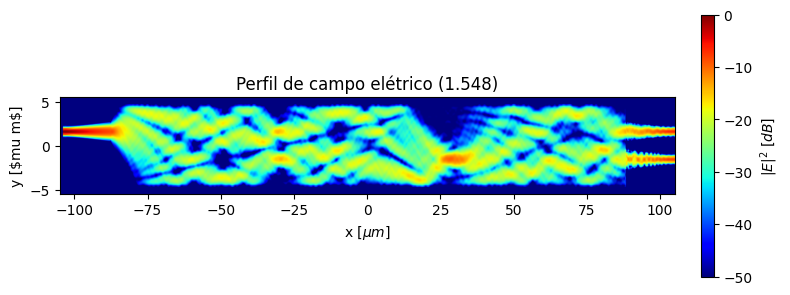

In [22]:
eFiled2 = np.power(eField[:,:,indxLambda], 2)
eField2 = eFiled2 / np.max(eFiled2)
eField2_dB = 10*np.log10(eField2)

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)

im = ax.imshow(np.rot90(eField2_dB), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin = -50, vmax = 0)

colorbar = plt.colorbar(im, fraction = 0.02, pad =0.04, label = r'$|E|^2$ $[dB]$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [\$mu m$]')
ax.set_title(r'Perfil de campo elétrico (%4.3f)' %(wavelength_array[indxLambda]/microns))
ax.set_aspect(3)

plt.tight_layout()
plt.show()

Parâmetros de transmissão

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_20000\3893347625.py:14: RuntimeWarning: invalid value encountered in log10
  ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)


Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

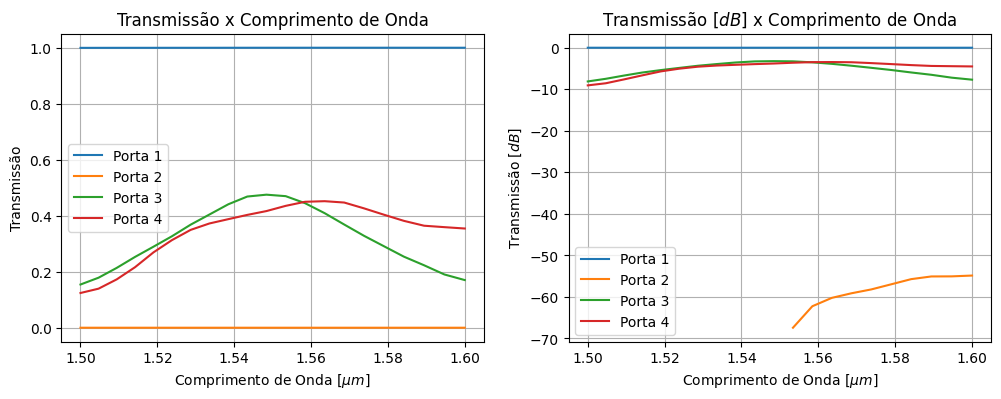

In [33]:
transmissao = [[], [], [], []]

lamb = [[], [], [], []]

#Transmissão do dispositivo em cada porta
fig, ax = plt.subplots(1,2, figsize=(12,4))

for i in range(1,5,1):
    ports = fdtdApi.getresult('FDTD::ports::porta%d' %i, 'T')
    transmissao[i-1] = ports['T']
    lamb[i-1] = ports['lambda']

    ax[0].plot(lamb[i-1]/microns, transmissao[i-1], label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

In [43]:
i = min(range(len(lamb[2])), key=lambda i: abs(lamb[2][i] - 1.55*microns))
print(transmissao[2][i])
print(transmissao[3][i])
print(lamb[2][i])

0.4752527631132318
0.4166877682444326
[1.5483871e-06]


C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_20000\3964429469.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_20000\3964429469.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


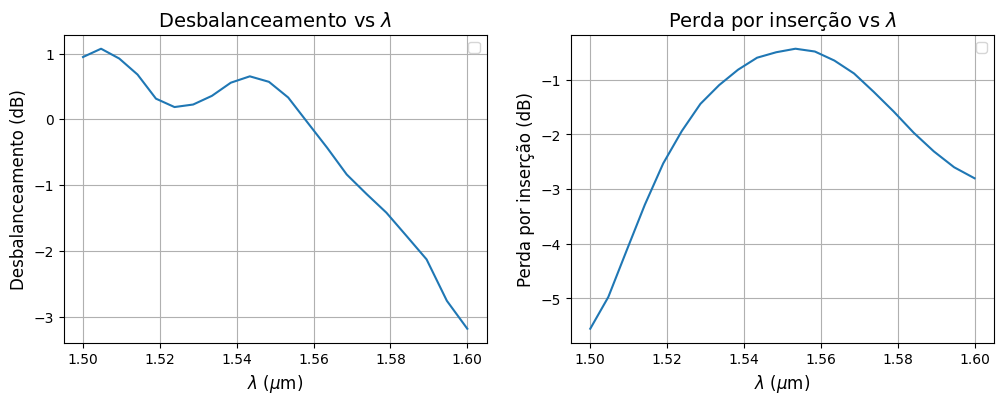

In [34]:
fig, axs = plt.subplots(1,2, figsize = (12,4))

# Imbalance

Ib = 10*np.log10(transmissao[2]) - 10*np.log10(transmissao[3])

axs[0].plot(lamb[2]/microns, Ib, lw = 1.5)
axs[0].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Desbalanceamento (dB)", fontsize = 12)
axs[0].set_title(r'Desbalanceamento vs $\lambda$', fontsize = 14)
axs[0].grid()
axs[0].legend()


# Insertion Loss

Il = 10*np.log10(transmissao[2] + transmissao[3])

axs[1].plot(lamb[2]/microns, Il, lw = 1.5)
axs[1].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Perda por inserção (dB)", fontsize = 12)
axs[1].set_title(r'Perda por inserção vs $\lambda$', fontsize = 14)
axs[1].grid()
axs[1].legend()